In [1]:
from comsar import TimbreTrack
from comsar import PitchTrack
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy import interpolate
from scipy.misc import derivative

In [2]:
import apollon.signal as signal
from apollon.signal.spectral import StftSegments
from apollon.segment import Segmentation
from timeit import default_timer as timer

In [3]:
from apollon.signal import container, features
import comsar
from comsar.tracks.utilities import (TrackMeta, TrackResult,
                                      TimbreTrackParams,  PitchTrackParams)

In [4]:
from comsar import PitchTrack
from apollon.audio import AudioFile
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from typing import Any, Optional
from scipy.interpolate import interp1d

import apollon.segment as aps
import apollon.signal.tools as ast
from IPython.display import Audio

In [5]:
params=aps.SegmentationParams(2205*2,2205+1764,True)
tt = PitchTrack(params)

In [6]:
sound1=np.zeros(int(44100/2))
for i in range(0,int(44100/2)):
    sound1[i] = np.sin(2 * np.pi * 498 * i / 44100)
    
a=tt.extract(sound1, 44100,'Beispiel')

Pitch ... 0.841 s.
SPL ... 0.002459 s.


In [7]:
#snd=AudioFile('C:/C/Rolf/comsar\comsar\TonalSystems\M1_Piano_Octave.wav')
cutter = Segmentation(2205, 1764,True, True)
segs = cutter.transform(sound1.squeeze())
stft=StftSegments(44100, 'hanning',None)
sxx = stft.transform(segs)
segs.data[0,:].size

50

In [139]:
ac=signal.tools.acf(segs.data[:,0])
zeroc = np.where(np.diff(np.signbit(ac)))[0]
maxa = max(ac[zeroc[0]:len(ac)])
maxs = np.where(ac == maxa)
ptch = 44100 /maxs[0][0]

TypeError: 'numpy.float64' object is not callable

In [296]:
fps=44100
waveletnum = 10
fm = 2004.5
nsteps = 50
#Frequency range due to fps between upper and lower adjacent autocorrelation delays
freqmax = 44100/(fps/fm-1)
freqmin = 44100/(fps/fm+1)
freqrange = (freqmax - freqmin)
amp = np.zeros(nsteps)
#Frequency step, depending on chosen nstep, resulting in frequency precision 
df = freqrange/nsteps
acf_seg = np.array([ast.acf(__s) for __s in np.atleast_2d(segs.data).T])
sig=segs.data[:,2]

for i in range(0,nsteps):
    freq = freqmin + df * i 
    #sin = np.zeros(int(waveletnum * fps / freq))
    #cos = np.zeros(int(waveletnum * fps / freq))
    sin = np.zeros(sig.size)
    cos = np.zeros(sig.size)
    #Standard Deviation of Gauss function 
    sigma = sin.size
    start = sig.size-sig.size
    for j in range(0,sig.size-1):
        sin[j] = np.sin(2 * np.pi * j * freq / fps) * np.exp(-(j-sin.size/2)**2/(sigma**2))
        cos[j] = np.cos(2 * np.pi * j * freq / fps) * np.exp(-(j-sin.size/2)**2/(sigma**2))

    amp[i] = np.sqrt((sin @ sig[start:sig.size])**2 + (cos @ sig[start:sig.size])**2)
    
maxw = np.max(amp)
maxf = freqmin + df * np.argmax(maxw == amp)
maxf

2012.301922859386

In [297]:
amp

array([ 48.60039599,  24.77826647,   8.49041469,  41.20998149,
        66.04128514,  75.15662273,  64.56327964,  35.18577639,
         8.39378243,  52.79610436,  88.86704095, 104.85137731,
        93.56594253,  54.09310211,   9.80996813,  78.6620927 ,
       140.33880446, 174.15863353, 163.59721521,  98.71734278,
        25.6709602 , 189.98226132, 384.22319165, 580.86767839,
       752.19508518, 873.01841023, 925.14245461, 900.66249183,
       803.40150496, 648.19470524, 458.16959312, 260.58650545,
        82.33803839,  58.35982304, 143.39253583, 173.46495184,
       155.05853164, 102.57995964,  34.63234234,  31.89767826,
        79.63109122, 101.36725445,  95.31544192,  66.47567328,
        24.65713565,  19.44520803,  53.42601595,  70.93322667,
        69.1211339 ,  50.21918284])

In [260]:
freqmin+df*5

1002.7879661719162

In [220]:
maxw

136.97617603817602

In [213]:
waveletnum * fps / freq

2342.8318959946005

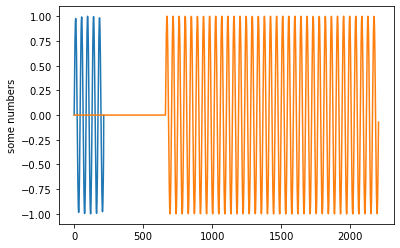

In [254]:
xc=range(0,cos.size)
xs=range(0,segs.data[:,2].size)
plt.plot(xc,sin, xs, segs.data[:,1])
plt.ylabel('some numbers')
plt.show()


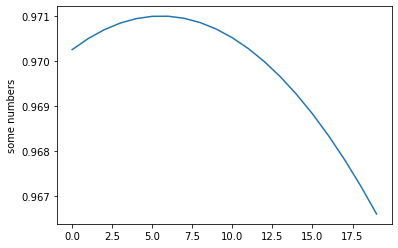

In [618]:
fps=44100
sig=segs.data
res = np.zeros(sig.data.shape[1])
ptch = np.zeros(sig.data.shape[1])
acf_seg = np.array([ast.acf(__s) for __s in np.atleast_2d(sig).T])

ninterpol=10

for i in range(0,sig.data.shape[1]):
    fzda = np.argmax(np.diff(acf_seg[i,:]<0), axis=0)
    max_acf = np.max(acf_seg[i,fzda:])
    max_idx = np.argmax(acf_seg[i,:]==max_acf)

    """
    width = 3
    sec = range(max_idx-width,max_idx+width)
    secnew = np.arange(max_idx-width,max_idx+width,.1)
    org = acf_seg[i,max_idx-width:max_idx+width]
    tck =  interpolate.splrep(sec , org, s=10)
    f =interpolate.splev(secnew, tck, der=0)

    max=np.max(f)
    maxw=np.argmax(f==max)

    max=np.max(org)
    maxa=np.argmax(org==max)
    """
    #res[i] = 44100/secnew[maxw]
    res[i] = fps/max_idx

    sec = range(0,segs.data.shape[0])
    secnew = np.arange(0,segs.data.shape[0],1/ninterpol)
    org = segs.data[:,1]
    tck =  interpolate.splrep(sec , org, s=0)
    f =interpolate.splev(secnew, tck, der=0)    

    amp = np.zeros(ninterpol*2)
    for j in range(0,ninterpol*2):
        delay = int(fps/res[i])*ninterpol-ninterpol+j
        f1 = np.concatenate((np.zeros(delay),f[0:f.size-delay]))
        amp[j] = f/np.linalg.norm(f) @ f1/np.linalg.norm(f1)

    maxa=np.max(amp)
    maxw=np.argmax(amp==maxa)
    
    res[i] = round(fps/(max_idx-1+maxw/ninterpol))
    
plt.plot(amp)
plt.ylabel('some numbers')
plt.show()

In [619]:
res

array([498., 498., 498., 498., 498., 498., 498., 498., 498., 498., 498.,
       498., 498., 498., 498., 498., 498., 498., 498., 498., 498., 498.,
       498., 498., 498., 498., 498., 498., 498., 498., 498., 498., 498.,
       498., 498., 498., 498., 498., 498., 498., 498., 498., 498., 498.,
       498., 498., 498., 498., 498., 498.])

In [19]:
sig[:,0].size

2205

In [8]:
dcent = 1
noctaves=1
f0=27.5
root=np.power(2,1/(1200/dcent))

result = np.empty((2,noctaves*12))

for ss in range(0,12 * noctaves-1):

    ff=np.power(root, ss * 100) * f0

    sound1=np.zeros(int(44100/2))
    for i in range(0,int(44100/2)):
        sound1[i] = np.sin(2 * np.pi * 2000 * i / 44100)
    
    #a=tt.extract(sound1, 44100,'Beispiel')

    cutter = Segmentation(2205*2, 2205+1764,True, True)
    segs = cutter.transform(sound1.squeeze())
    stft=StftSegments(44100, 'hanning',None)
    sxx = stft.transform(segs)
    segs.data[0,:].size

    fps=44100
    sig=segs.data
    res = np.zeros(sig.data.shape[1])
    ptch = np.zeros(sig.data.shape[1])
    acf_seg = np.array([ast.acf(__s) for __s in np.atleast_2d(sig).T])

    ninterpol=10
    n_perseg = segs.data.shape[0]

    for i in range(0,sig.data.shape[1]):
        fzda = np.argmax(np.diff(acf_seg[i,:]<0), axis=0)
        max_acf = np.max(acf_seg[i,fzda:])
        max_idx = np.argmax(acf_seg[i,:]==max_acf)

        res[i] = fps/max_idx

        R = np.mod(n_perseg,fps/(res[i]*2))
        p = fps/(res[i]*2)
        if R < p/2:
            res[i] = res[i] - p * np.sin(2 * np.pi *  R / ( 2 *p)) /(n_perseg)
        else:
            res[i] = res[i] - p * np.sin(2 * np.pi * (p - R)/(2 * p)) /(n_perseg)

        if res[i] > 1720:
            sec = range(0,sig.shape[0])
            secnew = np.arange(0,sig.shape[0],1/ninterpol)
            org = segs.data[:,i]
            tck =  interpolate.splrep(sec , org, s=0)
            f =interpolate.splev(secnew, tck, der=0)    

            amp = np.zeros(ninterpol*2)
            for j in range(0,ninterpol*2):
                delay = int(fps/res[i])*ninterpol-ninterpol+j
                f1 = np.concatenate((np.zeros(delay),f[0:f.size-delay]))
                amp[j] = f/np.linalg.norm(f) @ f1/np.linalg.norm(f1)

            maxa=np.max(amp)
            maxw=np.argmax(amp==maxa)
    
            res[i] = fps/(max_idx-1+maxw/ninterpol)
    
    result[0,ss] = ss*100
    result[1,ss] = np.power(root,np.min(res)/f0)
    print(ss)

0
1
2
3
4
5
6
7
8
9
10


In [5]:
st=20/(4000-1720)

In [6]:
10+st*(4000-1720)

30.0

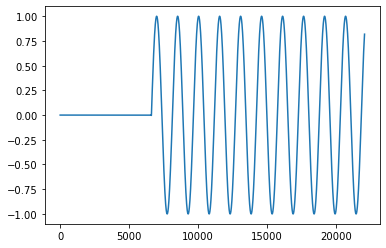

In [563]:
plt.plot(np.append(delay2,f[4205:f.size]))
plt.show()

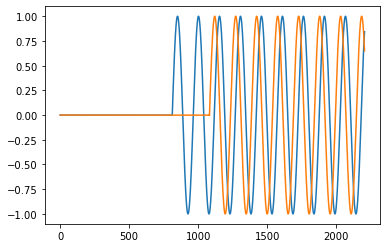

In [568]:
plt.plot(secnew,f1,secnew,f2)
plt.show()

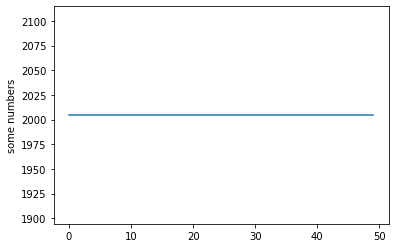

In [299]:
fps=44100
sig=segs.data
res = np.zeros(sig.data.shape[1])
ptch = np.zeros(sig.data.shape[1])
acf_seg = np.array([ast.acf(__s) for __s in np.atleast_2d(sig).T])

for i in range(0,sig.data.shape[1]):
    fzda = np.argmax(np.diff(acf_seg[i,:]<0), axis=0)
    max_acf = np.max(acf_seg[i,fzda:])
    max_idx = np.argmax(acf_seg[i,:]==max_acf)

    width = 3
    sec = range(max_idx-width,max_idx+width)
    secnew = np.arange(max_idx-width,max_idx+width,.1)
    org = acf_seg[i,max_idx-width:max_idx+width]
    tck =  interpolate.splrep(sec , org, s=10)
    f =interpolate.splev(secnew, tck, der=0)

    max=np.max(f)
    maxw=np.argmax(f==max)

    max=np.max(org)
    maxa=np.argmax(org==max)

    res[i] = 44100/sec[maxa]
    

    
plt.plot(res)
plt.ylabel('some numbers')
plt.show()

In [300]:
res

array([2004.54545455, 2004.54545455, 2004.54545455, 2004.54545455,
       2004.54545455, 2004.54545455, 2004.54545455, 2004.54545455,
       2004.54545455, 2004.54545455, 2004.54545455, 2004.54545455,
       2004.54545455, 2004.54545455, 2004.54545455, 2004.54545455,
       2004.54545455, 2004.54545455, 2004.54545455, 2004.54545455,
       2004.54545455, 2004.54545455, 2004.54545455, 2004.54545455,
       2004.54545455, 2004.54545455, 2004.54545455, 2004.54545455,
       2004.54545455, 2004.54545455, 2004.54545455, 2004.54545455,
       2004.54545455, 2004.54545455, 2004.54545455, 2004.54545455,
       2004.54545455, 2004.54545455, 2004.54545455, 2004.54545455,
       2004.54545455, 2004.54545455, 2004.54545455, 2004.54545455,
       2004.54545455, 2004.54545455, 2004.54545455, 2004.54545455,
       2004.54545455, 2004.54545455])

In [9]:
a.data[:,0]

array([290.13157895, 290.13157895, 290.13157895, 290.13157895,
       290.13157895, 290.13157895, 290.13157895, 290.13157895,
       290.13157895, 290.13157895, 290.13157895, 290.13157895,
       290.13157895, 290.13157895, 290.13157895, 290.13157895,
       290.13157895, 290.13157895, 290.13157895, 290.13157895,
       290.13157895, 290.13157895, 290.13157895, 290.13157895,
       290.13157895, 290.13157895, 290.13157895, 290.13157895,
       290.13157895, 290.13157895, 290.13157895, 290.13157895,
       290.13157895, 290.13157895, 290.13157895, 290.13157895,
       290.13157895, 290.13157895, 290.13157895, 290.13157895,
       290.13157895, 290.13157895, 290.13157895, 290.13157895,
       290.13157895, 290.13157895, 290.13157895, 290.13157895,
       290.13157895, 290.13157895])

In [20]:
args = [(segs.data, segs.n_segs, snd.fps)]
kwargs = [{}]
feature_names = ('Pitch Per Segment')

In [59]:
out

array([[183.75      ],
       [179.26829268],
       [199.54751131],
       [202.29357798],
       [202.29357798],
       [202.29357798],
       [202.29357798],
       [202.29357798],
       [202.29357798],
       [202.29357798],
       [202.29357798],
       [202.29357798],
       [203.22580645],
       [202.29357798],
       [202.29357798],
       [202.29357798],
       [202.29357798],
       [202.29357798],
       [202.29357798],
       [202.29357798],
       [202.29357798],
       [  0.        ]])

In [71]:
ac=snd.data[:,0]@snd.data[:,0]
ac

450.8634847085923

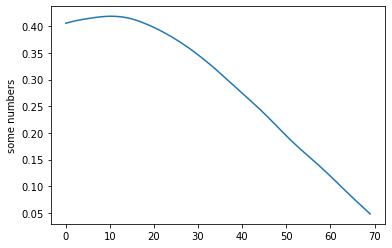

In [148]:
plt.plot(ac[230:300])
plt.ylabel('some numbers')
plt.show()

In [3]:
a=tt.extract('C:/C/Rolf/Wavelet_Release/Git d-Ap-L(a).wav')

Spectral Centroid ... 0.02333 s.
Spectral Spread ... 0.05122 s.
Spectral Flux ... 0.001877 s.
Roughness ... 0.7009 s.
Sharpness ... 0.01739 s.
SPL ... 0.001505 s.
Correlation Dimension ... 3.035 s.
Correlogram ... 50.11 s.


In [8]:
a.features

,Spectral Centroid,Spectral Spread,Spectral Flux,Roughness,Sharpness,SPL,Correlation Dimension,Correlogram
0,275.503501,421.493650,0.231047,313.931144,0.051864,74.728248,0.000000,0.071239
1,345.691866,513.765600,0.006890,173.019924,0.031178,75.313977,4.575173,0.149813
2,322.963302,317.327840,0.005415,43.636507,0.004506,66.714950,3.429802,0.121327
3,379.882754,285.247393,0.037776,20.983007,0.002367,56.069321,0.000000,0.041234


In [4]:
from apollon.audio import AudioFile

In [5]:
snd=AudioFile('C:/C/Rolf/Wavelet_Release/Git d-Ap-L(a).wav')

In [12]:
snd.n_frames

44249

In [10]:
tt.params

TimbreTrackParams(stft=StftParams(fps=44100, window='hamming', n_fft=None, n_perseg=32768, n_overlap=16384, extend=True, pad=True), corr_dim=CorrDimParams(delay=14, m_dim=80, n_bins=1000, scaling_size=10), corr_gram=CorrGramParams(wlen=1024, n_delay=256, total=True))